## Image viewer

In this notebook, we show several ways to look at images\
Craig Lage - 13-Mar-21

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pf
from lsst.daf.persistence import Butler
import lsst.afw.cameraGeom.utils as camGeomUtils
import lsst.afw.display as afwDisplay

In [2]:
# Get the quickLook data
# This has had some level of ISR done to it, including overscan subtraction
# and bias subtraction, so the images are better
REPO_DIR = '/project/shared/auxTel/rerun/quickLook'
butler = Butler(REPO_DIR)
dayObs = '2021-03-11'
expId=2021031100184
exp = butler.get('quickLookExp', detector=0, expId=expId)
mean = np.mean(exp.getMaskedImage().getArrays()[0])
std = np.std(exp.getMaskedImage().getArrays()[0])
print(mean, std)

Ignoring translator header fixup of LATISS AT_O_20210311_000184: 'MJD-OBS not found'


16.80926 398.411


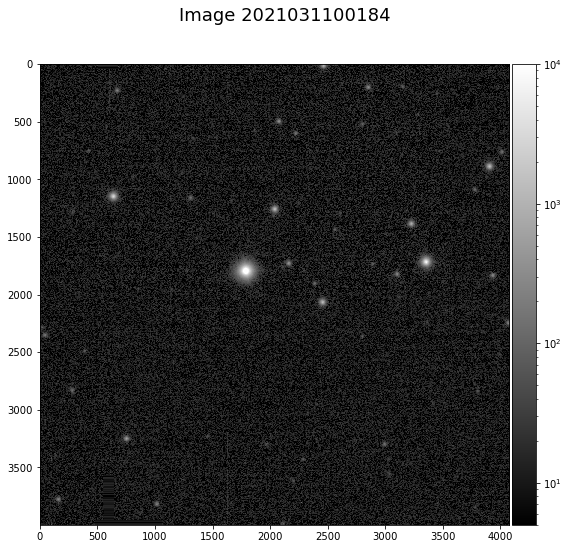

In [13]:
# Look at the data with matplotlib
from matplotlib.colors import LogNorm
# Now let's look at ithem
def colorbar(mappable):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    plt.sca(last_axes)
    return cbar

plt.figure(figsize=(8,8))
plt.suptitle(f"Image {expId}",fontsize=18)
arr = exp.image.array
arr = np.clip(arr, 1, 150000) # This image has some negative values, and this removes them
img = plt.imshow(arr,  norm=LogNorm(vmin=5, vmax=10000), interpolation='Nearest', cmap='gray')
colorbar(img)
plt.tight_layout(h_pad=1)
#plt.savefig(REPO_DIR+"/plots/NGC4755_17Feb21.pdf")